In [18]:
papers = {
   'Shakespeare': [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    
    'Test': [
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 33, 34, 35, 36, 37, 38, 39, 40
    # ,
    # 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
    # 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
    # 61, 62, 63, 64, 65, 66, 67, 68, 69, 70,
    # 71, 72, 73, 74, 75, 76, 77, 78, 79, 80,
    # 81, 82, 83, 84, 85, 86, 87, 88, 89, 90,
    # 91, 92, 93, 94, 95, 96, 97, 98, 99, 100,
    # 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
    # 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
    # 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
    # 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
    # 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
    # 151, 152, 153, 154
    ],

    'Gem': [
    155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
    165, 166, 167, 168, 169, 170, 171, 172, 173, 174
    ],

    'ChatGPT': [
    175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
    185, 186, 187, 188, 189, 190, 191, 192, 193, 194
    ]

    }


# A function that compiles all of the text files associated with a single author into a single string
def read_files_into_string(filenames):
    strings = []
    for filename in filenames:
        with open(f'data/sonnet_{filename}.txt', 'r') as f:
            strings.append(f.read())
    return '\n'.join(strings)

# Make a dictionary out of the authors' corpora
by_author = {}
for author, files in papers.items():
    by_author[author] = read_files_into_string(files)

for author in papers:
    print(by_author[author][:100])

I

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as the
XXI

So is it not with me as with that Muse,
Stirr’d by a painted beauty to his verse,
Who heaven it
CLV

If from the heavy earth my thoughts could rise,
To seek the sun that in thy glory reigns,
Then 
CLXXV

Why dost thou hide thy light in jealous shade,
As though the sun were debtor to the night?
Wh


[nltk_data] Downloading package punkt to /home/aleksander-
[nltk_data]     elkins/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/aleksander-
[nltk_data]     elkins/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


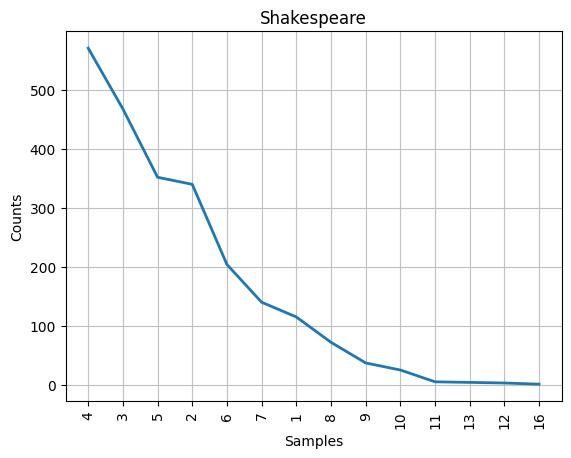

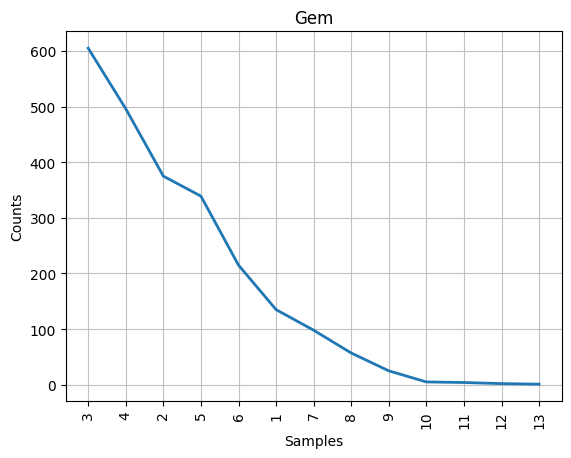

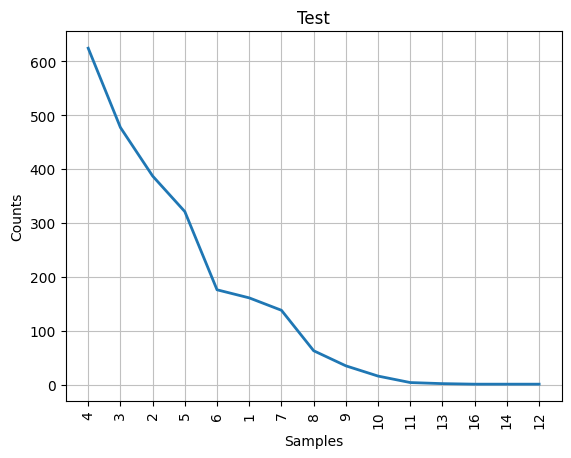

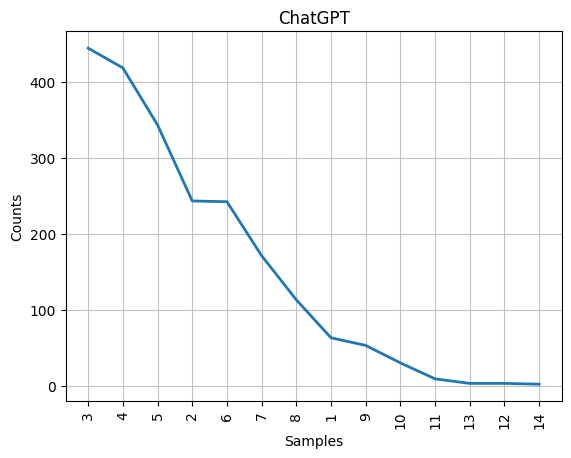

In [19]:
# Load nltk
import nltk
nltk.download(['punkt', 'punkt_tab'])
import matplotlib.pyplot as plt
%matplotlib inline

# Compare the disputed papers to those written by everyone,
# including the shared ones.
authors = ("Shakespeare", "Gem", "Test", "ChatGPT")

# Transform the authors' corpora into lists of word tokens
federalist_by_author_tokens = {}
federalist_by_author_length_distributions = {}
for author in authors:
    tokens = nltk.word_tokenize(by_author[author])

    # Filter out punctuation
    federalist_by_author_tokens[author] = ([token for token in tokens
                                            if any(c.isalpha() for c in token)])

    # Get a distribution of token lengths
    token_lengths = [len(token) for token in federalist_by_author_tokens[author]]
    federalist_by_author_length_distributions[author] = nltk.FreqDist(token_lengths)
    plt.figure()
    federalist_by_author_length_distributions[author].plot(15,title=author)


In [20]:
# Who are the authors we are analyzing?
authors = ("Shakespeare", "Gem", "ChatGPT")

# Lowercase the tokens so that the same word, capitalized or not,
# counts as one word
for author in authors:
    federalist_by_author_tokens[author] = (
        [token.lower() for token in federalist_by_author_tokens[author]])
federalist_by_author_tokens["Test"] = (
    [token.lower() for token in federalist_by_author_tokens["Test"]])

# Calculate chisquared for each of the two candidate authors
for author in authors:

    # First, build a joint corpus and identify the 500 most frequent words in it
    joint_corpus = (federalist_by_author_tokens[author] +
                    federalist_by_author_tokens["Test"])
    joint_freq_dist = nltk.FreqDist(joint_corpus)
    most_common = list(joint_freq_dist.most_common(500))

    # What proportion of the joint corpus is made up
    # of the candidate author's tokens?
    author_share = (len(federalist_by_author_tokens[author])
                    / len(joint_corpus))

    # Now, let's look at the 500 most common words in the candidate
    # author's corpus and compare the number of times they can be observed
    # to what would be expected if the author's papers
    # and the Disputed papers were both random samples from the same distribution.
    chisquared = 0
    for word,joint_count in most_common:

        # How often do we really see this common word?
        author_count = federalist_by_author_tokens[author].count(word)
        disputed_count = federalist_by_author_tokens["Test"].count(word)

        # How often should we see it?
        expected_author_count = joint_count * author_share
        expected_disputed_count = joint_count * (1-author_share)

        # Add the word's contribution to the chi-squared statistic
        chisquared += ((author_count-expected_author_count) *
                       (author_count-expected_author_count) /
                       expected_author_count)

        chisquared += ((disputed_count-expected_disputed_count) *
                       (disputed_count-expected_disputed_count)
                       / expected_disputed_count)

    print("The Chi-squared statistic for candidate", author, "is", chisquared)


The Chi-squared statistic for candidate Shakespeare is 802.031836184036
The Chi-squared statistic for candidate Gem is 1173.389164962856
The Chi-squared statistic for candidate ChatGPT is 1005.2340778369795


In [21]:
# Who are we dealing with this time?
authors = ("Shakespeare", "Gem", "ChatGPT")

# Convert papers to lowercase to count all tokens of the same word together
# regardless of case
for author in authors:
    federalist_by_author_tokens[author] = (
        [tok.lower() for tok in federalist_by_author_tokens[author]])

# Combine every paper except our test case into a single corpus
whole_corpus = []
for author in authors:
    whole_corpus += federalist_by_author_tokens[author]

# Get a frequency distribution
whole_corpus_freq_dist = list(nltk.FreqDist(whole_corpus).most_common(30))
whole_corpus_freq_dist[ :10 ]

# The main data structure
features = [word for word,freq in whole_corpus_freq_dist]
feature_freqs = {}

for author in authors:
    # A dictionary for each candidate's features
    feature_freqs[author] = {}

    # A helper value containing the number of tokens in the author's subcorpus
    overall = len(federalist_by_author_tokens[author])

    # Calculate each feature's presence in the subcorpus
    for feature in features:
        presence = federalist_by_author_tokens[author].count(feature)
        feature_freqs[author][feature] = presence / overall


import math

# The data structure into which we will be storing the "corpus standard" statistics
corpus_features = {}

# For each feature...
for feature in features:
    # Create a sub-dictionary that will contain the feature's mean
    # and standard deviation
    corpus_features[feature] = {}

    # Calculate the mean of the frequencies expressed in the subcorpora
    feature_average = 0
    for author in authors:
        feature_average += feature_freqs[author][feature]
    feature_average /= len(authors)
    corpus_features[feature]["Mean"] = feature_average

    # Calculate the standard deviation using the basic formula for a sample
    feature_stdev = 0
    for author in authors:
        diff = feature_freqs[author][feature] - corpus_features[feature]["Mean"]
        feature_stdev += diff*diff
    feature_stdev /= (len(authors) - 1)
    feature_stdev = math.sqrt(feature_stdev)
    corpus_features[feature]["StdDev"] = feature_stdev


feature_zscores = {}
for author in authors:
    feature_zscores[author] = {}
    for feature in features:

        # Z-score definition = (value - mean) / stddev
        # We use intermediate variables to make the code easier to read
        feature_val = feature_freqs[author][feature]
        feature_mean = corpus_features[feature]["Mean"]
        feature_stdev = corpus_features[feature]["StdDev"]
        feature_zscores[author][feature] = ((feature_val-feature_mean) /
                                            feature_stdev)

# Tokenize the test case
testcase_tokens = nltk.word_tokenize(by_author["Test"])

# Filter out punctuation and lowercase the tokens
testcase_tokens = [token.lower() for token in testcase_tokens
                   if any(c.isalpha() for c in token)]

# Calculate the test case's features
overall = len(testcase_tokens)
testcase_freqs = {}
for feature in features:
    presence = testcase_tokens.count(feature)
    testcase_freqs[feature] = presence / overall

# Calculate the test case's feature z-scores
testcase_zscores = {}
for feature in features:
    feature_val = testcase_freqs[feature]
    feature_mean = corpus_features[feature]["Mean"]
    feature_stdev = corpus_features[feature]["StdDev"]
    testcase_zscores[feature] = (feature_val - feature_mean) / feature_stdev

for author in authors:
    delta = 0
    for feature in features:
        delta += math.fabs((testcase_zscores[feature] -
                            feature_zscores[author][feature]))
    delta /= len(features)
    print( "Delta score for candidate", author, "is", delta )



Delta score for candidate Shakespeare is 0.9524800492076658
Delta score for candidate Gem is 1.433365616190127
Delta score for candidate ChatGPT is 1.3216416092086314
